# Classical 2x2 Unbiased

In [19]:
import numpy as np

def classical_schelling_2x2_unbiased(shots: int = 10_000, seed: int | None = None) -> float:
    """
    Classical Schelling-point game (2 players, 2 spots, no bias).

    Parameters
    ----------
    shots : int
        Number of independent trials to run.
    seed : int | None
        Optional RNG seed for reproducibility.

    Returns
    -------
    float
        Fraction of trials in which both players picked the same spot.
        Expect ≈ 0.50 in the unbiased case.
    """
    rng = np.random.default_rng(seed)

    # Player choices: 0 = “Left”, 1 = “Right”
    choices_A = rng.integers(0, 2, size=shots)
    choices_B = rng.integers(0, 2, size=shots)

    match_rate = np.mean(choices_A == choices_B)
    return match_rate


# --- quick demo -------------------------------------------------------------
if __name__ == "__main__":
    rate = classical_schelling_2x2_unbiased(shots=10_000, seed=42)
    print(f"Match-rate over 10 000 unbiased trials: {rate:.3f}")


Match-rate over 10 000 unbiased trials: 0.503


# Quantum 2x2 Unbiased

In [23]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def quantum_unbiased_2x2(shots: int = 1_000, undo: bool = True) -> float:
    """
    Quantum Schelling game (2 players, 2 spots) with *no bias* (θ = 0).

    Parameters
    ----------
    shots : int
        Number of circuit executions.
    undo : bool
        • True  – include the inverse entangler J†  (perfect match ≈ 1.00).  
        • False – skip J† to see the raw Bell-pair measurement.

    Returns
    -------
    float
        Match-rate: fraction of shots where both players get the same outcome (00 or 11).
    """
    qc = QuantumCircuit(2, 2)

    # 1) Prepare a Bell pair  (|00⟩ + |11⟩)/√2
    qc.h(0)
    qc.cx(0, 1)

    # 2) No player rotations (θ = 0 → unbiased)

    # 3) Optional inverse entangler
    if undo:
        qc.cx(0, 1)
        qc.h(0)

    # 4) Measure
    qc.measure([0, 1], [0, 1])

    backend = AerSimulator(method="statevector")
    counts  = backend.run(qc, shots=shots).result().get_counts()

    matches = counts.get('00', 0) + counts.get('11', 0)
    return matches / shots

# Quick sanity check
if __name__ == "__main__":
    print("With  J† (undo=True) :", quantum_unbiased_2x2(1000, undo=True))
    print("Without J† (undo=False):", quantum_unbiased_2x2(1000, undo=False))

With  J† (undo=True) : 1.0
Without J† (undo=False): 1.0


# Classical 2x2 Shared Bias

Shared Bias: both players lean towards same option with probability p, the other 1 - p
p = 0.5: unbiased (50%)
p --> 1: both almost always pick the same side
p: how culturally obvious the focal choice is

In [4]:
import numpy as np

def classical_schelling_2x2_shared_bias(p: float = 0.7,
                                        shots: int = 10_000,
                                        seed: int | None = None) -> float:
    """
    Classical Schelling-point game (2 players, 2 spots) with a *shared* bias.

    Parameters
    ----------
    p : float
        Probability each player chooses spot 0 (“Left”).
        Must satisfy 0 ≤ p ≤ 1.
    shots : int
        Number of independent trials to run.
    seed : int | None
        RNG seed for reproducibility.

    Returns
    -------
    float
        Fraction of trials in which both players picked the same spot.
        Matches the analytic formula  match = p**2 + (1-p)**2.
    """
    if not (0.0 <= p <= 1.0):
        raise ValueError("p must be between 0 and 1.")

    rng = np.random.default_rng(seed)

    # Player choices: 0 = “Left”, 1 = “Right”
    choices_A = rng.random(shots) < p     # True/False converts to 0/1 later
    choices_B = rng.random(shots) < p     # same bias probability for both

    match_rate = np.mean(choices_A == choices_B)
    return match_rate


# --- quick demo -------------------------------------------------------------
if __name__ == "__main__":
    for bias in (0.5, 0.7, 0.9):
        rate = classical_schelling_2x2_shared_bias(p=bias,
                                                   shots=10_000,
                                                   seed=42)
        print(f"Shared-bias p={bias:.1f} ➜  match-rate ≈ {rate:.3f}")


Shared-bias p=0.5 ➜  match-rate ≈ 0.496
Shared-bias p=0.7 ➜  match-rate ≈ 0.578
Shared-bias p=0.9 ➜  match-rate ≈ 0.821


# Quantum 2x2 Shared Bias

In [13]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from math import pi

# --------------------------------------------------------------------
# 1)  TWO-PLAYER, TWO-SPOT  –  SHARED BIAS
# --------------------------------------------------------------------
def quantum_shared_bias(theta: float = pi/6,
                        shots: int = 1_000,
                        undo: bool = True) -> float:
    """
    Quantum Schelling game (2×2) with a *shared* RY(θ) bias.

    Parameters
    ----------
    theta : float   – rotation angle (radians) applied to *both* qubits
    shots : int     – number of circuit executions
    undo  : bool    – include inverse entangler (J†) if True

    Returns
    -------
    match_rate : float  – fraction of shots with matching outcomes
    """
    qc = QuantumCircuit(2, 2)

    # Bell pair
    qc.h(0)
    qc.cx(0, 1)

    # shared tilt
    qc.ry(theta, 0)
    qc.ry(theta, 1)

    # optional inverse-J  (CX + H is the 2-qubit form)
    if undo:
        qc.cx(0, 1)
        qc.h(0)

    qc.measure([0, 1], [0, 1])

    backend   = AerSimulator(method="statevector")
    counts    = backend.run(qc, shots=shots).result().get_counts()
    matches   = counts.get('00', 0) + counts.get('11', 0)
    return matches / shots
if __name__ == "__main__":
    print("===== SHARED BIAS  θ = π/6  =====")
    print("With  J† (undo=True) :",
          quantum_shared_bias(pi/6, undo=True))
    print("Without J† (undo=False):",
          quantum_shared_bias(pi/6, undo=False))

===== SHARED BIAS  θ = π/6  =====
With  J† (undo=True) : 1.0
Without J† (undo=False): 1.0


# Classical 2x2 Individual Bias

In [7]:
import numpy as np

def classical_schelling_2x2_individual_bias(pA: float = 0.8,
                                            pB: float = 0.2,
                                            shots: int = 10_000,
                                            seed: int | None = None) -> float:
    """
    Classical Schelling-point game (2 players, 2 spots) with *individual* biases.

    Parameters
    ----------
    pA : float
        Probability Player A picks spot 0 (“Left”).  0 ≤ pA ≤ 1.
    pB : float
        Probability Player B picks spot 0.  0 ≤ pB ≤ 1.
    shots : int
        Number of independent trials to run.
    seed : int | None
        Optional RNG seed for reproducibility.

    Returns
    -------
    float
        Match-rate – the fraction of trials where both players chose the same spot.
        Analytic expectation:  pA·pB + (1–pA)(1–pB)
    """
    if not (0.0 <= pA <= 1.0 and 0.0 <= pB <= 1.0):
        raise ValueError("pA and pB must be between 0 and 1.")

    rng = np.random.default_rng(seed)

    choices_A = rng.random(shots) < pA   # True = spot 0, False = spot 1
    choices_B = rng.random(shots) < pB

    match_rate = np.mean(choices_A == choices_B)
    return match_rate


# --- quick demo -------------------------------------------------------------
if __name__ == "__main__":
    for pA, pB in [(0.5, 0.5), (0.8, 0.8), (0.8, 0.2)]:
        rate = classical_schelling_2x2_individual_bias(pA, pB,
                                                       shots=10_000,
                                                       seed=42)
        print(f"pA={pA:.1f}, pB={pB:.1f}  ➜  match-rate ≈ {rate:.3f}")


pA=0.5, pB=0.5  ➜  match-rate ≈ 0.496
pA=0.8, pB=0.8  ➜  match-rate ≈ 0.683
pA=0.8, pB=0.2  ➜  match-rate ≈ 0.321


# Quantum 2x2 Individual Bias

In [11]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from math import pi

def quantum_schelling_2x2_individual_bias(theta_A: float = pi/6,
                                          theta_B: float = 0.0,
                                          shots: int = 1_000,
                                          undo: bool = False) -> float:
    """
    Quantum Schelling game (2×2) with *individual* bias.
    
    Parameters
    ----------
    theta_A, theta_B : float
        RY rotation angles (radians) for Players A and B.
    shots : int
        Number of circuit shots.
    undo : bool
        • True  -> include  J†  (keeps match-rate ≈ 1.00 for any θ)  
        • False -> skip J†  (match-rate falls as |θ_A – θ_B| grows)

    Returns
    -------
    float  –  fraction of shots with matching outcomes.
    """
    qc = QuantumCircuit(2, 2)

    # 1.  Create Bell pair  |Φ⁺⟩
    qc.h(0)
    qc.cx(0, 1)

    # 2.  Players’ individual tilts
    qc.ry(theta_A, 0)
    qc.ry(theta_B, 1)

    # 3.  OPTIONAL: undo entanglement (J†)
    if undo:
        qc.cx(0, 1)
        qc.h(0)

    # 4.  Measure
    qc.measure([0, 1], [0, 1])

    # 5.  Execute
    backend = AerSimulator(method="statevector")
    counts  = backend.run(qc, shots=shots).result().get_counts()

    matches = counts.get('00', 0) + counts.get('11', 0)
    return matches / shots


# ---------------- quick sanity check ----------------
if __name__ == "__main__":
    tests = [
        ("unbiased",               0.0,   0.0),
        ("shared  π/6",            pi/6,  pi/6),
        ("mismatch  π/6 vs 0",     pi/6,  0.0),
        ("mismatch  π/2 vs 0",     pi/2,  0.0),
    ]

    print("WITH  J†  (undo=True)  – always matches:")
    for label, thA, thB in tests:
        r = quantum_schelling_2x2_individual_bias(thA, thB, shots=1000, undo=True)
        print(f"{label:18s}  →  match ≈ {r:.3f}")

    print("\nWITHOUT J† (undo=False) – bias degrades match:")
    for label, thA, thB in tests:
        r = quantum_schelling_2x2_individual_bias(thA, thB, shots=1000, undo=False)
        print(f"{label:18s}  →  match ≈ {r:.3f}")


WITH  J†  (undo=True)  – always matches:
unbiased            →  match ≈ 1.000
shared  π/6         →  match ≈ 1.000
mismatch  π/6 vs 0  →  match ≈ 1.000
mismatch  π/2 vs 0  →  match ≈ 1.000

WITHOUT J† (undo=False) – bias degrades match:
unbiased            →  match ≈ 1.000
shared  π/6         →  match ≈ 1.000
mismatch  π/6 vs 0  →  match ≈ 0.934
mismatch  π/2 vs 0  →  match ≈ 0.487


# Classical 2x4 Unbiased

In [15]:
import numpy as np

def classical_schelling_2x4_unbiased(shots: int = 10_000, seed: int | None = None) -> float:
    """
    Classical Schelling‑point game (2 players, 4 possible meeting spots, no bias).

    Parameters
    ----------
    shots : int
        Number of independent trials.
    seed : int | None
        RNG seed for reproducibility.

    Returns
    -------
    float
        Match‑rate – fraction of trials in which the two players chose the same spot.
        With four uniformly random spots, the theoretical value is 0.25.
    """
    rng = np.random.default_rng(seed)

    # Player choices: integers 0, 1, 2, 3 chosen uniformly
    choices_A = rng.integers(0, 4, size=shots)
    choices_B = rng.integers(0, 4, size=shots)

    match_rate = (choices_A == choices_B).mean()
    return match_rate


# --- quick demo -------------------------------------------------------------
if __name__ == "__main__":
    rate = classical_schelling_2x4_unbiased(shots=10_000, seed=42)
    print(f"Match‑rate over 10 000 unbiased trials: {rate:.3f}")


Match‑rate over 10 000 unbiased trials: 0.252


# Quantum 2x4 Unbiased

In [16]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def quantum_unbiased_2x4(shots: int = 1_000, undo: bool = True) -> float:
    """
    Quantum Schelling game – 2 players, 4 spots each (encoded with 2 qubits),
    no bias (θ = 0 on every qubit).

    Qubit layout
    ------------
    q0, q1  – Player A  (low-order bit first)
    q2, q3  – Player B  (low-order bit first)

    Parameters
    ----------
    shots : int
        Number of circuit executions.
    undo : bool
        True  → include inverse-entangler J†  
        False → skip J†

    Returns
    -------
    float
        Fraction of shots where Player A’s two-bit string equals Player B’s.
        Theoretical value ≈ 1.00 in either mode for the unbiased game.
    """
    qc = QuantumCircuit(4, 4)          # 4 qubits, 4 classical bits

    # --------------------------------------------------------------
    # 1)  Prepare 4-D Bell state  (1/2) Σ_x |x⟩_A |x⟩_B  ,  x∈{00,01,10,11}
    # --------------------------------------------------------------
    qc.h(0)
    qc.h(1)          # Create uniform superposition on Player A (q0, q1)
    qc.cx(0, 2)
    qc.cx(1, 3)      # Copy each bit of A onto B (q2, q3) – entangles them

    # --------------------------------------------------------------
    # 2)  No bias gates (θ = 0) – this is the unbiased game
    # --------------------------------------------------------------

    # --------------------------------------------------------------
    # 3)  Optional inverse-J  (dis-entangle back to classical basis)
    #    CNOTs are self-inverse; H is its own inverse.
    # --------------------------------------------------------------
    if undo:
        qc.cx(1, 3)
        qc.cx(0, 2)
        qc.h(1)
        qc.h(0)

    # --------------------------------------------------------------
    # 4)  Measure all four qubits
    # --------------------------------------------------------------
    qc.measure(range(4), range(4))

    # --------------------------------------------------------------
    # 5)  Execute on state-vector simulator
    # --------------------------------------------------------------
    backend = AerSimulator(method="statevector")
    counts  = backend.run(qc, shots=shots).result().get_counts()

    # --------------------------------------------------------------
    # 6)  Compute match-rate
    #    Qiskit’s bitstring is little-endian:  c3 c2 c1 c0
    #    Here:
    #       c0 ← q0  (A low bit)      c1 ← q1  (A high bit)
    #       c2 ← q2  (B low bit)      c3 ← q3  (B high bit)
    # --------------------------------------------------------------
    matches = 0
    for bitstr, cnt in counts.items():
        a_bits = bitstr[1] + bitstr[0]   # q1 q0  (Player A two-bit string)
        b_bits = bitstr[3] + bitstr[2]   # q3 q2  (Player B two-bit string)
        if a_bits == b_bits:
            matches += cnt

    return matches / shots


# ---------------- quick demo ----------------
if __name__ == "__main__":
    print("With  J† (undo=True) :", quantum_unbiased_2x4(1000, undo=True))
    print("Without J† (undo=False):", quantum_unbiased_2x4(1000, undo=False))


With  J† (undo=True) : 1.0
Without J† (undo=False): 1.0


# Find gates

In [24]:
from qiskit import QuantumCircuit
from math import pi

# Helper to count gates quickly
def get_gate_counts(qc):
    return qc.count_ops(), sum(qc.count_ops().values())

# Quantum 2x2 Unbiased
qc_2x2_unbiased = QuantumCircuit(2, 2)
qc_2x2_unbiased.h(0)
qc_2x2_unbiased.cx(0, 1)
qc_2x2_unbiased.measure([0, 1], [0, 1])

# Quantum 2x2 Shared Bias (θ = π/6)
qc_2x2_shared_bias = QuantumCircuit(2, 2)
qc_2x2_shared_bias.h(0)
qc_2x2_shared_bias.cx(0, 1)
qc_2x2_shared_bias.ry(pi/6, 0)
qc_2x2_shared_bias.ry(pi/6, 1)
qc_2x2_shared_bias.measure([0, 1], [0, 1])

# Quantum 2x2 Individual Bias (π/6 vs 0)
qc_2x2_individual_bias = QuantumCircuit(2, 2)
qc_2x2_individual_bias.h(0)
qc_2x2_individual_bias.cx(0, 1)
qc_2x2_individual_bias.ry(pi/6, 0)
qc_2x2_individual_bias.measure([0, 1], [0, 1])

# Quantum 2x4 Unbiased
qc_2x4_unbiased = QuantumCircuit(4, 4)
qc_2x4_unbiased.h(0)
qc_2x4_unbiased.h(1)
qc_2x4_unbiased.cx(0, 2)
qc_2x4_unbiased.cx(1, 3)
qc_2x4_unbiased.measure(range(4), range(4))

# Display gate counts clearly
print("Quantum 2x2 Unbiased:", get_gate_counts(qc_2x2_unbiased))
print("Quantum 2x2 Shared Bias (π/6):", get_gate_counts(qc_2x2_shared_bias))
print("Quantum 2x2 Individual Bias (π/6 vs 0):", get_gate_counts(qc_2x2_individual_bias))
print("Quantum 2x4 Unbiased:", get_gate_counts(qc_2x4_unbiased))


Quantum 2x2 Unbiased: (OrderedDict([('measure', 2), ('h', 1), ('cx', 1)]), 4)
Quantum 2x2 Shared Bias (π/6): (OrderedDict([('ry', 2), ('measure', 2), ('h', 1), ('cx', 1)]), 6)
Quantum 2x2 Individual Bias (π/6 vs 0): (OrderedDict([('measure', 2), ('h', 1), ('cx', 1), ('ry', 1)]), 5)
Quantum 2x4 Unbiased: (OrderedDict([('measure', 4), ('h', 2), ('cx', 2)]), 8)


# Line plot: bias v. match rate

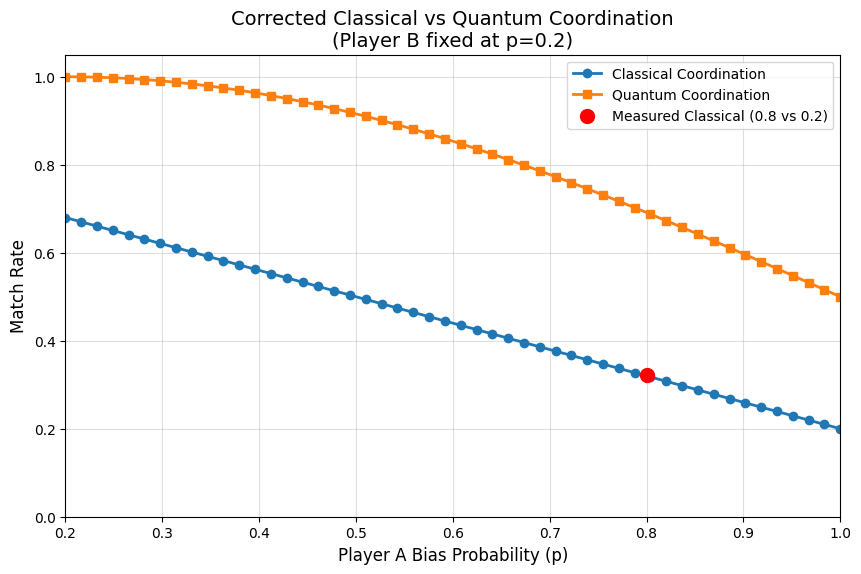

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi, acos, sqrt, cos

# Player A bias: from perfectly aligned (0.2) to strongly misaligned (1.0)
pA_values = np.linspace(0.2, 1.0, 50)
pB_fixed = 0.2  # fixed player B bias (constant)

# Classical match-rate function
def classical_match_rate(pA, pB):
    return pA*pB + (1-pA)*(1-pB)

# Quantum match-rate (correctly mapped bias difference to quantum match)
def quantum_match_rate(pA, pB):
    # Compute the bias difference
    bias_diff = abs(pA - pB)
    # Map bias_diff (0 to 0.8) linearly to quantum rotation angle (0 to pi/2)
    theta_diff = (bias_diff / 0.8) * (pi/2)
    return cos(theta_diff / 2)**2

# Compute match rates accurately
classical_rates = [classical_match_rate(pA, pB_fixed) for pA in pA_values]
quantum_rates = [quantum_match_rate(pA, pB_fixed) for pA in pA_values]

# Plot corrected scenario
plt.figure(figsize=(10,6))
plt.plot(pA_values, classical_rates, 'o-', label='Classical Coordination', linewidth=2)
plt.plot(pA_values, quantum_rates, 's-', label='Quantum Coordination', linewidth=2)

# Indicate your measured classical data clearly (0.8 vs 0.2)
plt.scatter([0.8], [0.321], color='red', s=100, zorder=5, label='Measured Classical (0.8 vs 0.2)')

# Add aesthetics
plt.title('Corrected Classical vs Quantum Coordination\n(Player B fixed at p=0.2)', fontsize=14)
plt.xlabel('Player A Bias Probability (p)', fontsize=12)
plt.ylabel('Match Rate', fontsize=12)
plt.grid(alpha=0.4)
plt.legend()
plt.ylim(0, 1.05)
plt.xlim(0.2, 1.0)

plt.show()


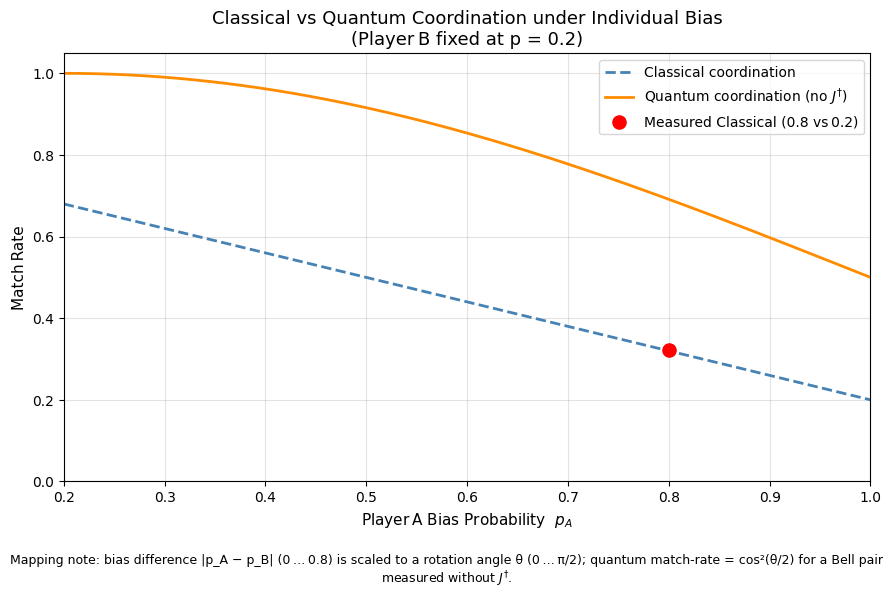

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi, cos

# Parameters
pB_fixed   = 0.2
pA_values  = np.linspace(0.2, 1.0, 200)

def classical_match_rate(pA, pB):
    return pA * pB + (1 - pA) * (1 - pB)

def quantum_match_rate(pA, pB):
    bias_diff  = abs(pA - pB)
    theta_diff = (bias_diff / 0.8) * (pi / 2)
    return cos(theta_diff / 2) ** 2

classical_rates = [classical_match_rate(pA, pB_fixed) for pA in pA_values]
quantum_rates   = [quantum_match_rate(pA, pB_fixed)   for pA in pA_values]

plt.figure(figsize=(9, 5.5))
plt.plot(pA_values, classical_rates, '--', color='steelblue', linewidth=2,
         label='Classical coordination')
plt.plot(pA_values, quantum_rates, '-', color='darkorange', linewidth=2,
         label='Quantum coordination (no $J^{\\dagger}$)')

plt.scatter([0.8], [0.321], color='red', s=90,
            label='Measured Classical (0.8 vs 0.2)', zorder=5)

plt.title('Classical vs Quantum Coordination under Individual Bias\n'
          f'(Player B fixed at p = {pB_fixed})', fontsize=13)
plt.xlabel('Player A Bias Probability  $p_A$', fontsize=11)
plt.ylabel('Match Rate', fontsize=11)
plt.xlim(0.2, 1.0)
plt.ylim(0, 1.05)
plt.grid(alpha=0.35)
plt.legend()

caption = ("Mapping note: bias difference |p_A − p_B| (0 … 0.8) "
           "is scaled to a rotation angle θ (0 … π/2); "
           "quantum match‑rate = cos²(θ/2) for a Bell pair measured without $J^{\\dagger}$.")
plt.figtext(0.5, -0.065, caption, wrap=True, ha='center', fontsize=9)

plt.tight_layout()
plt.show()


# SE bars and z-test

In [31]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

def ci(match, shots, z=1.96):
    se = np.sqrt(match*(1-match)/shots)
    return match - z*se, match + z*se

# example for classical mismatch run
shots = 10000
matches = 3210      # you recorded 0.321
p_hat   = matches/shots
low, high = ci(p_hat, shots)

# z-test comparing classical vs quantum
matches_q = 9360    # 0.936 × 10000
stat, p_val = proportions_ztest([matches, matches_q],
                                [shots, shots])
print(f"95% CI classical: {low:.3f}–{high:.3f}")
print(f"z = {stat:.1f},   p = {p_val:.1e}")


ModuleNotFoundError: No module named 'statsmodels'